python -m venv venv
venv\Scripts\activate
pip install numpy matplotlib tensorflow scikit-learn
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
pip install notebook
python -m notebook

TensorFlow/Pytorch implementation of CNN

In [56]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

In [57]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [58]:
# Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

# Add channel dimension (important for CNN)
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(f'Training data shape: {x_train.shape}')
print(f'Test data shape: {x_test.shape}')

Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


In [59]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Labels:", [{i: name} for i, name in enumerate(class_names)])

Labels: [{0: 'T-shirt/top'}, {1: 'Trouser'}, {2: 'Pullover'}, {3: 'Dress'}, {4: 'Coat'}, {5: 'Sandal'}, {6: 'Shirt'}, {7: 'Sneaker'}, {8: 'Bag'}, {9: 'Ankle boot'}]


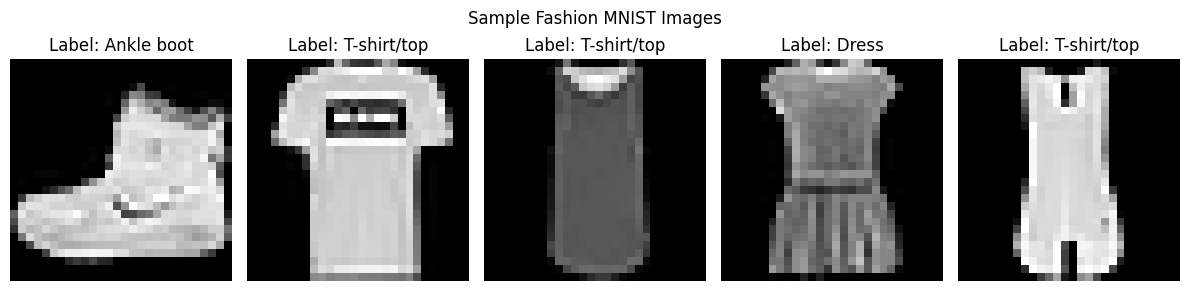

In [60]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    axes[i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {class_names[y_train[i]]}')
    axes[i].axis('off')

plt.suptitle('Sample Fashion MNIST Images')
plt.tight_layout()
plt.show()

In [61]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

C:\A-Projects-gng\practicals\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape               ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                  │ (None, 26, 26, 32)         │            320 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ max_pooling2d_6 (MaxPooling2D)     │ (None, 13, 13, 32)         │              0 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ conv2d_9 (Conv2D)                  │ (None, 11, 11, 64)         │         18,496 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ max_pooling2d_7 (MaxPooling2D)     │ (None, 5, 5, 64)           │              0 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ flatten_3 (Flatten)                │ (None, 1600)               │              0 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dense_6 (Dense)                    │ (None, 64)                 │        102,464 │
├────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dense_7 (Dense)                    │ (None, 10)                 │            650 │
└────────────────────────────────────┴────────────────────────────┴────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [63]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=2
)

Epoch 1/5
844/844 - 22s - 27ms/step - accuracy: 0.8171 - loss: 0.5064 - val_accuracy: 0.8720 - val_loss: 0.3571
Epoch 2/5
844/844 - 18s - 21ms/step - accuracy: 0.8765 - loss: 0.3391 - val_accuracy: 0.8757 - val_loss: 0.3329
Epoch 3/5
844/844 - 16s - 19ms/step - accuracy: 0.8930 - loss: 0.2945 - val_accuracy: 0.8950 - val_loss: 0.2874
Epoch 4/5
844/844 - 16s - 19ms/step - accuracy: 0.9038 - loss: 0.2673 - val_accuracy: 0.8917 - val_loss: 0.3017
Epoch 5/5
844/844 - 22s - 26ms/step - accuracy: 0.9095 - loss: 0.2447 - val_accuracy: 0.9000 - val_loss: 0.2620


In [64]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Loss: 0.2800
Test Accuracy: 0.8961


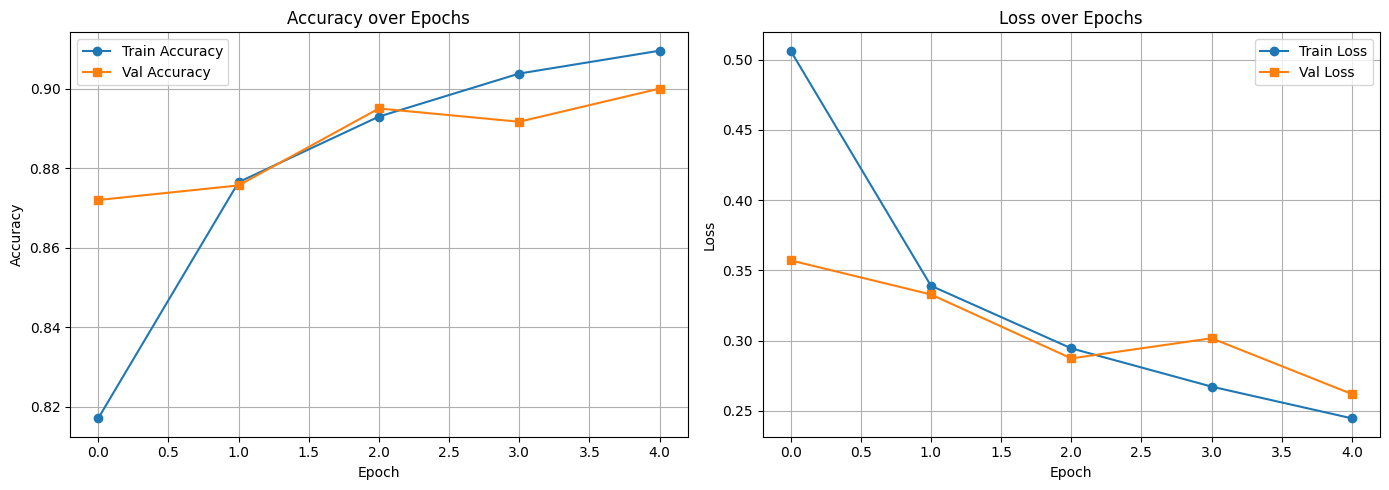

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Val Loss', marker='s')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

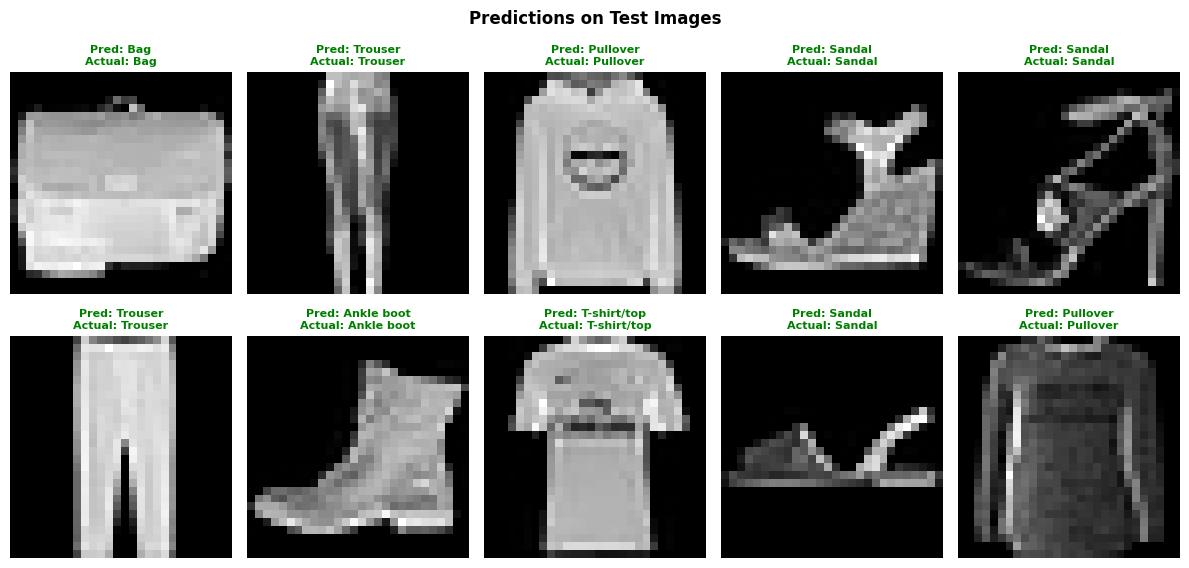

In [66]:
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
y_true = y_test.flatten()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i in range(10):
    idx = np.random.randint(0, len(x_test))
    ax = axes[i//5, i%5]

    ax.imshow(x_test[idx].squeeze(), cmap='gray')

    pred = class_names[y_pred[idx]]
    actual = class_names[y_true[idx]]

    color = 'green' if pred == actual else 'red'

    ax.set_title(f'Pred: {pred}\nActual: {actual}',
                 color=color, fontweight='bold', fontsize=8)
    ax.axis('off')

plt.suptitle('Predictions on Test Images', fontweight='bold')
plt.tight_layout()
plt.show()